![](https://raw.githubusercontent.com/quantumjot/btrack/main/docs/_static/btrack_logo.png)

# Example of using btrack to track cells in timelapse microscopy data

This notebook covers the following functionality:

* Load segmentation data and localize objects
* Load a table of localized objects 
* Run tracking algorithm
* Inspect the output
* Visualize the results in napari

In addition, we have an extensive tutorial of the cell tracking application as part of *napari*:  

https://napari.org/tutorials/tracking/cell_tracking.html

In [6]:
!uv pip install btrack matplotlib "napari[all]<0.6.0"

Resolved 137 packages in 25ms
Installed 5 packages in 112ms
 + contourpy==1.3.2
 + cycler==0.12.1
 + fonttools==4.57.0
 + matplotlib==3.10.1
 + pyparsing==3.2.3


## Importing btrack and loading example datasets

In [7]:
import btrack

from btrack import datasets

We can automatically download some example data to play with:

In [9]:
CONFIG_FILE = datasets.cell_config()
SEGMENTATION_FILE = datasets.example_segmentation_file()
OBJECTS_FILE = datasets.example_track_objects_file()

## Finding objects to track

### Use case 1 - Objects from segmentation

These could be objects found using algorithms such as a UNet, *CellPose* or *StarDist*. We can use `scikit-image` to load the segmentation data, which returns a numpy array of dimensions (T, Y, X).

In [10]:
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.util import montage

In [11]:
segmentation = imread(SEGMENTATION_FILE)

In [12]:
segmentation.shape

(500, 1200, 1600)

### show the segmentation as a montage

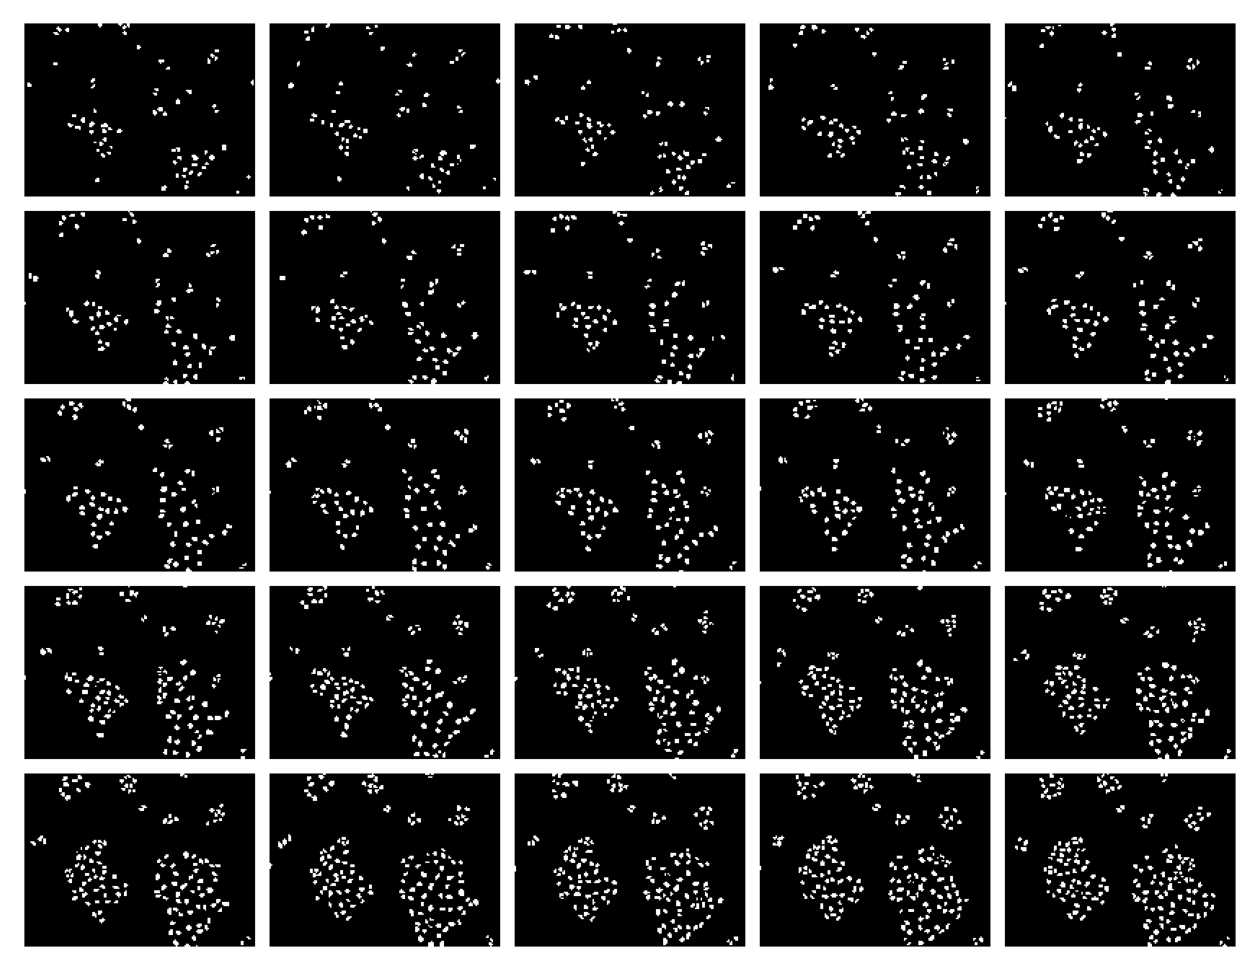

In [13]:
seq = montage(
    segmentation[::20, ::10, ::10], 
    grid_shape=(5, 5), 
    padding_width=10, 
    fill=255,
)

fig, ax = plt.subplots(1, figsize=(16, 16))
ax.imshow(seq, cmap=plt.cm.gray)
ax.axis(False)
plt.show()

### localize the objects

Now we use a utility function to localise the objects in the segmentation. Note that we can also use scikit-image `regionprops` to calculate properties for each object, using the `properties` keyword:

In [14]:
FEATURES = [
    "area", 
    "major_axis_length", 
    "minor_axis_length", 
    "orientation", 
    "solidity"
]

objects = btrack.utils.segmentation_to_objects(
    segmentation, 
    properties=tuple(FEATURES), 
    num_workers=4,  # parallelise this
)

[INFO][2025/04/17 11:30:39 AM] Localizing objects from segmentation...
[INFO][2025/04/17 11:30:39 AM] Processing using 4 workers.
progress: 100%|██████████| 500/500 [00:22<00:00, 22.56it/s]
[INFO][2025/04/17 11:31:02 AM] Objects are of type: <class 'dict'>
[INFO][2025/04/17 11:31:02 AM] ...Found 52890 objects in 500 frames.


We can also inspect each returned object to determine it's properties:

In [15]:
objects[0]

,ID,x,y,z,t,dummy,states,label,area,major_axis_length,minor_axis_length,orientation,solidity
0,0,517.573657,9.07279,0.0,0,False,7,5,577.0,33.260603,22.856213,1.455708,0.968121


## Running the tracking

In [16]:
# initialise a tracker session using a context manager
with btrack.BayesianTracker() as tracker:

    # configure the tracker using a config file
    tracker.configure(CONFIG_FILE)
    tracker.max_search_radius = 50
    tracker.tracking_updates = ["MOTION", "VISUAL"]
    tracker.features = FEATURES

    # append the objects to be tracked
    tracker.append(objects)

    # set the tracking volume
    tracker.volume=((0, 1600), (0, 1200))

    # track them (in interactive mode)
    tracker.track(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks in a format for napari visualization
    data, properties, graph = tracker.to_napari()
    
    # store the tracks
    tracks = tracker.tracks
    
    # store the configuration
    cfg = tracker.configuration
    
    # export the track data 
    # tracker.export("tracks.h5", obj_type="obj_type_1")
    

[INFO][2025/04/17 11:31:04 AM] Loaded btrack: C:\Users\timmo\Documents\GitHub\napari-demo\.venv\Lib\site-packages\btrack\libs\libtracker.DLL
[INFO][2025/04/17 11:31:04 AM] Starting BayesianTracker session
[INFO][2025/04/17 11:31:04 AM] Loading configuration file: C:\Users\timmo\AppData\Local\btrack-examples\btrack-examples\Cache\examples\cell_config.json
[INFO][2025/04/17 11:31:04 AM] Objects are of type: <class 'list'>
[INFO][2025/04/17 11:31:04 AM] Starting tracking... 
[INFO][2025/04/17 11:31:04 AM] Update using: ['MOTION', 'VISUAL']
[INFO][2025/04/17 11:31:04 AM] Tracking objects in frames 0 to 99 (of 500)...
[INFO][2025/04/17 11:31:04 AM]  - Timing (Bayesian updates: 1.00ms, Linking: 0.00ms)
[INFO][2025/04/17 11:31:04 AM]  - Probabilities (Link: 1.00000, Lost: 1.00000)
[INFO][2025/04/17 11:31:04 AM]  - Stats (Active: 78, Lost: 48, Conflicts resolved: 114)
[INFO][2025/04/17 11:31:04 AM] Tracking objects in frames 100 to 199 (of 500)...
[INFO][2025/04/17 11:31:05 AM]  - Timing (Baye

## Inspecting the output

We can also inspect each returned track to determine it's properties:

In [17]:
cell = tracks[1]

In [18]:
cell

,ID,t,x,y,z,parent,root,state,generation,dummy,orientation,solidity,area,minor_axis_length,major_axis_length
0,53,0,717.819372,8.738220,0.000000,53,53,5,0,False,0.869672,0.976982,382.0,21.801409,23.171147
1,53,1,718.919771,8.392550,0.000000,53,53,5,0,False,0.811202,0.977591,349.0,19.626382,23.510687
2,53,2,720.060000,7.882857,0.000000,53,53,5,0,False,1.072452,0.972222,350.0,18.792250,24.582280
3,53,3,720.187075,6.442177,0.000000,53,53,5,0,False,1.308400,0.973510,294.0,16.551330,23.750930
4,53,4,720.664179,5.720149,0.000000,53,53,5,0,False,1.376156,0.964029,268.0,15.016468,23.978545
5,53,5,721.241379,4.980843,0.000000,53,53,5,0,False,1.467654,0.973881,261.0,13.587210,26.049419
6,53,6,718.248869,4.443439,0.000000,53,53,5,0,False,1.422753,0.956710,221.0,12.198129,24.880723
7,53,7,716.811828,3.844086,0.000000,53,53,5,0,False,1.482713,0.978947,186.0,10.577681,23.540772
8,53,8,713.819277,3.349398,0.000000,53,53,5,0,False,1.482035,0.948571,166.0,9.576197,23.698689
9,53,9,713.131579,2.947368,0.000000,53,53,5,0,False,1.499213,0.955975,152.0,8.903715,24.135198


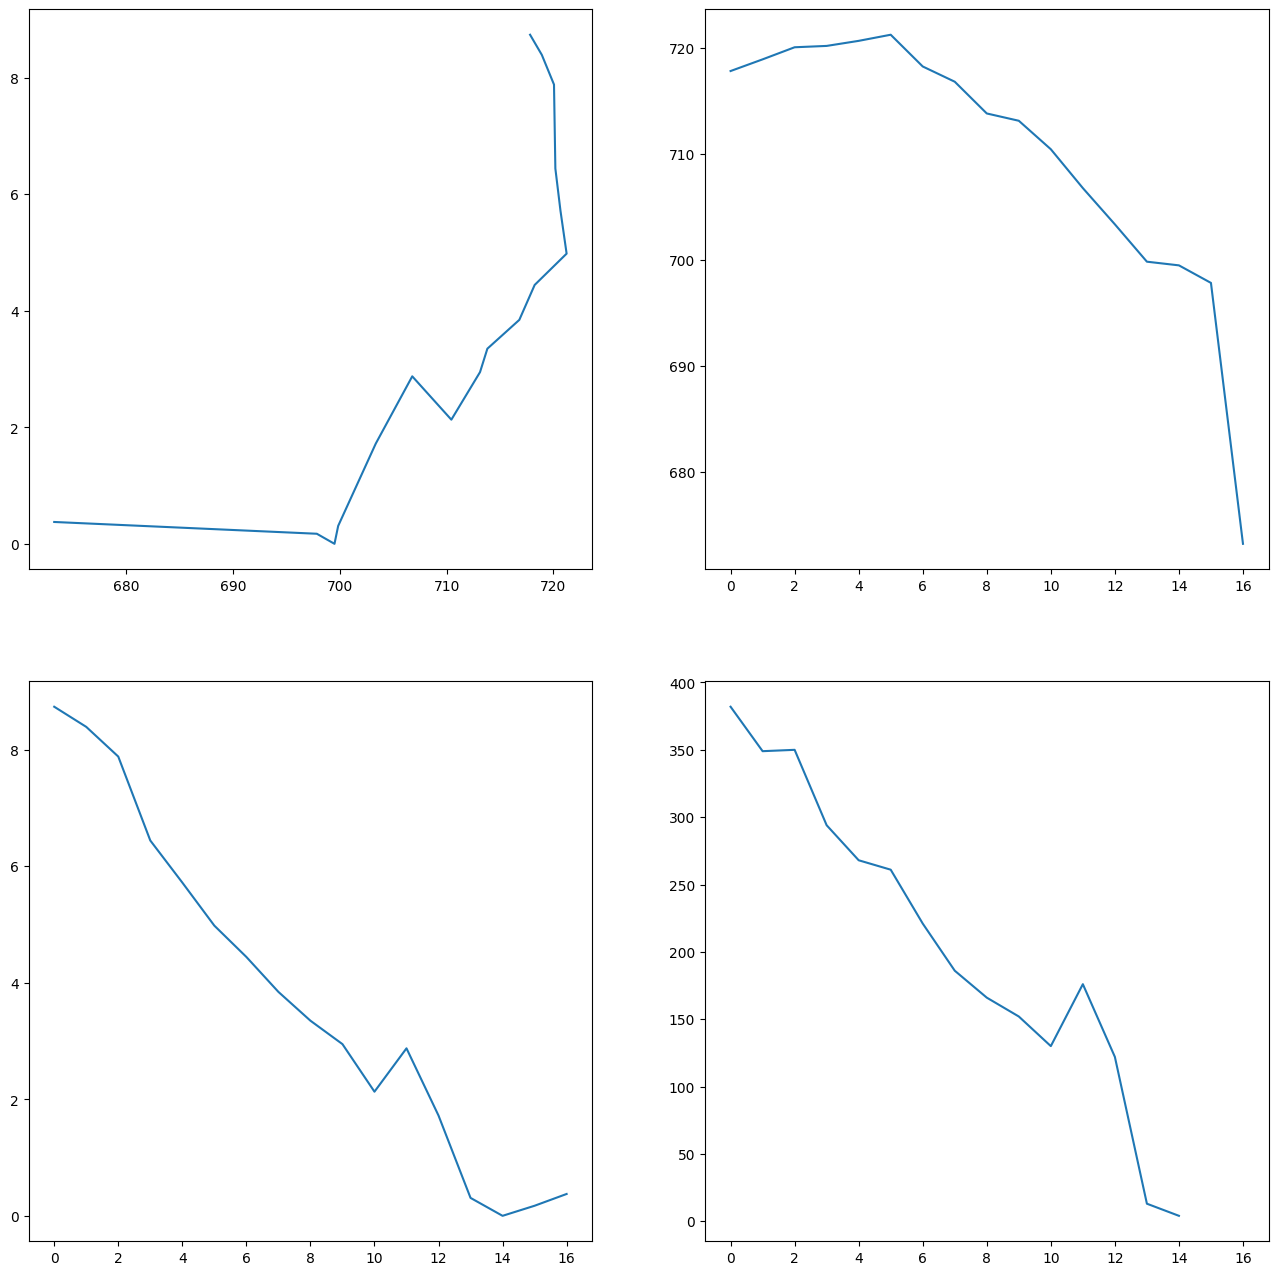

In [19]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 16))
ax1.plot(cell.x, cell.y)
ax2.plot(cell.t, cell.x)
ax3.plot(cell.t, cell.y)
ax4.plot(cell.t, cell["area"])
plt.show()

## Visualising the data with napari

Finally, we an inspect the entire tracking output using *napari*:

In [20]:
import napari

viewer = napari.Viewer()

viewer.add_labels(
    segmentation, 
    name="Segmentation",
    opacity=0.5,
)

# the track data from the tracker
viewer.add_tracks(
    data, 
    properties=properties, 
    graph=graph, 
    name="Tracks", 
    blending="translucent",
    visible=True,
)

<Tracks layer 'Tracks' at 0x21b4d7f0590>